In [8]:
from langgraph.graph import StateGraph,START,END;

from typing import Annotated,TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import AIMessage,BaseMessage,HumanMessage,SystemMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

True

In [9]:
class chatbot_State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

# ? base message is the parent class of all messages, it can be human message, ai message or system message. we can use it to store all messages in the state. and we can use the add_messages function to add messages to the state.


In [10]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash",temperature=0.7)
def chat_node(state:chatbot_State):
   messages=state["messages"]

   response=llm.invoke(messages)

   return {'messages':[response]}




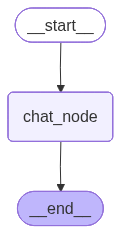

In [11]:
checkpointer=MemorySaver() # * define the checkpointer to save the state of the chatbot, so that we can use it later to continue the conversation.
graph=StateGraph(chatbot_State)

graph.add_node("chat_node",chat_node)

graph.add_edge(START,"chat_node")
graph.add_edge("chat_node",END)

workflow=graph.compile(checkpointer=checkpointer) # * compile the graph with the checkpointer, so that we can save the state of the chatbot after each node execution.

workflow

In [13]:
# initial_message={
#     "messages":[
#       HumanMessage(content="give me a powerful Life Quote ?")
#     ]
# }

# workflow.invoke(initial_message)

# *
thread_id=1
while True:
    user_input=input("user:")

    print("user input=",user_input)

    if(user_input.strip().lower() in ["exit","quit"]):
        print("Exiting the chatbot. Goodbye!")
        break
    else:
        initial_message={
            "messages":[
              HumanMessage(content=user_input)
            ]
        }
        config={'configurable':{"thread_id":thread_id}} # ? we can use the thread_id to identify the conversation thread, so that we can save the state of the chatbot for each conversation thread separately.
        response=workflow.invoke(initial_message, config=config)

        print("chatbot:",response["messages"][-1].content)



user input= hi what is 10 + 10
chatbot: [{'type': 'text', 'text': '10 + 10 is 20!', 'extras': {'signature': 'EvYFCvMFAQw51sd16HVs74h79wEeP+DpOih66Uh0ckhW9E3g6U+56RhJF/tjc2lMAI1GnG6HFW3eAd4+m4E6dohX8gZYOYMg3LdIaW+WM4Hot4o74F+YMu37vBz+tsO68pNAoAJwE5EVyzQZ4wvlVyNNSS6ByexAbe9TiZrM0iuT6D4WPbOxKhXrfS35esQkMYpM6fHcdTy4B+nuFr0weGRAVr0QRY1b9B5C4A7/drua5jjMv8yH3ysCYH8UcRP+s2/MBtpJiFUsK2M55U2nI82VRYICVgTPym2G0xdtIKpK16YQjO09kZVE7kYfCdUjcXCbrR78OImUS/0ufQcN+ew/xucMu9p7a1YFSc/P/RVJpPthr9GyDL0mqg14PixbjeJq816nqUSuPQYoDnJXusFghiDr8btaYjjMmG7IKN5sFL2ysRe6KYyFCRIb3fYponi9hzaT0VCZzvTyRGXS/QS95CByT56nRM+KWLFPJZV5tbZ9Ilc/I0ke69o0PJ9L5OyhXfiO3ruDli/XrjHQxNKYMmcJWD1zS+V5m3MGUdbkzi1ReagnobXMfS390AOXZeERB7JcDwbV1L5pLpFZy07Y6uTEbBxmx3m/eyUG72TVh9OXDx32ZbhkRBzzuzcs54/i0xHvzX/yvZKs2iigS+6uuzqpev6wHkBofA6V6v1qPUem8pj/LVGpqMd+GN87DrB2xF7u7UHbrzPbT6aROyrT6k3MTgFxycBxDD8DtaeNkRV7p6t6tKBUxe5IwYUoG7z7ISi0H0uo8omSAp2+0598nMDag96TC8bvtwy61KoKZR4zglQG7tI3bTeSQtWSAFnZMaISHEUQsYDoZnkHdosex02S13FwQUTe/hU93Qry0i+BYA8xuCSE/RR

In [14]:
workflow.get_state(config=config) # ? we can use the get_state function to get the state of the chatbot for a specific conversation thread, so that we can continue the conversation later.

StateSnapshot(values={'messages': [HumanMessage(content='hello i am parv', additional_kwargs={}, response_metadata={}, id='72d79614-6002-4a7d-8fad-2ef9997946dd'), AIMessage(content=[{'type': 'text', 'text': "Hello Parv! It's great to meet you. How can I help you today?", 'extras': {'signature': 'EvIGCu8GAQw51scSf0AUUTf7GdAj8g0FgbUnUluOr8y2HnimEnA8zzO63YMjJDKzxOXG9XRCMdm0qaYL3/8yXmlrNqk3MyxOgxgvBDmsZJT8dEk7+hYdaIMYZweQQxQ3OYWlJ80cfbfQVP2saBNvJEo3js+oddZTKAuHnW1DUl2iySU4g+e6cNKKDF+4lILbDrEXY2BUxRM4n3dHFsbStrG2Y0UQ15qNPIZIGO1shKtKaLgBItg0NEE5zaDMy1X8k+91aO/xS6BCOay1/r8NBDxCjWqAj+i/y3M9zk14WP2swm3mE4xyy8+n3hO5A77+joZMh50k+SRjt0vbsma/QF5rUN+Z3FVv4cIJFGrdNIGV7yTTKMcOyy69MsolPDkmpAJSWc3p97EzRh3MbqKpvjgibWfJe52PaLAxatLMQbV/ybWLKDBnxoThHrtxxBBg6NBqBW0rEhV8fhFkBHxU4dmp83kjHz+TwbBS/AgTbW/iriCjAP0TnXNeHOH83tHqkAHL80sp3u9WEpnwzr1qXDSQBNSMdxEQR4ctSKbGqVdNVLBuOEv4VuhmZ4q1A0knU2qbjWlilcbljD5CtdaOmxPl9EsmrMRyRr2swwGLy3g5xmso6wWdH6aC9rFrmJdtn61m1P/l1qWkFBMX1G2PGG9UB3unK4yzCiqGaLQ5UZXxA4lfS+fNKO0EnNg56S1